In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os 
import cv2
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [10]:
def load_dataset(root,image_size=(128,128)):
    images,masks=[],[]
    for tile in sorted(os.listdir(root)): #her bir tile klasorunu sırayla dolasma
        img_dir=os.path.join(root,tile,"images") #goruntulerin oldugu klasorler
        mask_dir=os.path.join(root,tile,"masks") #masklerin oldugu klasorler
        if not os.path.isdir(img_dir): continue
        for f in os.listdir(img_dir): #goruntu dosyalarını dolasma
            if not f.lower().endswith(".jpg"): continue
            img_path=os.path.join(img_dir,f)#goruntu dosya yolu
            mask_path=os.path.join(mask_dir,os.path.splitext(f)[0]+".png")
            if not os.path.exists(mask_path): continue

            img=cv2.cvtColor(cv2.imread(img_path),cv2.COLOR_BGR2RGB)
            img=cv2.resize(img,image_size)/255.0

            mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
            mask=cv2.resize(mask,image_size)
            mask=np.expand_dims(mask,axis=-1)/255.0

            images.append(img)
            masks.append(mask)
    return np.array(images,dtype="float32"),np.array(masks,dtype="float32")

In [11]:
X,y=load_dataset(r"C:\dl_proje\image_process\U-Net\arial_segment")

In [13]:
len(y)

72

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [15]:
len(X_train)

57

In [16]:
len(X_test)

15

In [20]:
def unet_model(input_size=(128,128,3)):
    inputs=keras.Input(input_size)

    #encode kısmını olusturma
    c1=layers.Conv2D(16,3,activation="relu",padding="same")(inputs)
    c1=layers.Conv2D(16,3,activation="relu",padding="same")(c1)
    p1=layers.MaxPooling2D()(c1)

    c2=layers.Conv2D(32,3,activation="relu",padding="same")(p1)
    c2=layers.Conv2D(32,3,activation="relu",padding="same")(c2)
    p2=layers.MaxPooling2D()(c2)

    c3=layers.Conv2D(64,3,activation="relu",padding="same")(p2)
    c3=layers.Conv2D(64,3,activation="relu",padding="same")(c3)
    p3=layers.MaxPooling2D()(c3)

    c4=layers.Conv2D(64,3,activation="relu",padding="same")(p3)
    c4=layers.Conv2D(64,3,activation="relu",padding="same")(c4)
    p4=layers.MaxPooling2D()(c4)

    #bottlenech : en derin seviye
    c5=layers.Conv2D(256,3,activation="relu",padding="same")(p4)
    c5=layers.Conv2D(256,3,activation="relu",padding="same")(c5)

    #decoder up sampling ve skip connection

    u6=layers.Conv2DTranspose(128,2,strides=(2,2),padding="same")(c5)
    u6=layers.concatenate([u6,c4])
    c6=layers.Conv2D(128,3,activation="relu",padding="same")(u6)
    c6=layers.Conv2D(128,3,activation="relu",padding="same")(c6)

    u7=layers.Conv2DTranspose(64,2,strides=(2,2),padding="same")(c6)
    u7=layers.concatenate([u7,c3])
    c7=layers.Conv2D(64,3,activation="relu",padding="same")(u7)
    c7=layers.Conv2D(64,3,activation="relu",padding="same")(c7)

    u8=layers.Conv2DTranspose(32,2,strides=(2,2),padding="same")(c7)
    u8=layers.concatenate([u8,c2])
    c8=layers.Conv2D(32,3,activation="relu",padding="same")(u8)
    c8=layers.Conv2D(32,3,activation="relu",padding="same")(c8)

    u9=layers.Conv2DTranspose(16,2,strides=(2,2),padding="same")(c8)
    u9=layers.concatenate([u9,c1])
    c9=layers.Conv2D(16,3,activation="relu",padding="same")(u9)
    c9=layers.Conv2D(16,3,activation="relu",padding="same")(c9)

    outputs=layers.Conv2D(1,1,activation="sigmoid")(c9)
    return keras.Model(inputs,outputs)

In [21]:
unet_model=unet_model()
unet_model.compile(optimizer="adam",loss="binary_crossentropy")

callback=[
        keras.callbacks.ModelCheckpoint("model_best.h5",save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(),
        keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)

    
]

In [33]:
history=unet_model.fit(
        X_train,y_train,
    validation_data=(X_test,y_test),
    epochs=100,
    batch_size=16,
    callbacks=callback

    
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - loss: 0.6596 - val_loss: 0.6637 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.6578

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step - loss: 0.6581 - val_loss: 0.6610 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - loss: 0.6588

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - loss: 0.6586 - val_loss: 0.6602 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - loss: 0.6555 - val_loss: 0.6614 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - loss: 0.6573 - val_loss: 0.6602 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - loss: 0.6584

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 617ms/step - loss: 0.6578 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - loss: 0.6560 - val_loss: 0.6598 - learning_rate: 0.0010
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - loss: 0.6547 - val_loss: 0.6586 - learning_rate: 0.0010
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 0.6539

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - loss: 0.6540 - val_loss: 0.6580 - learning_rate: 0.0010
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - loss: 0.6552

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - loss: 0.6550 - val_loss: 0.6578 - learning_rate: 0.0010
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - loss: 0.6537 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 0.6535

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - loss: 0.6535 - val_loss: 0.6570 - learning_rate: 0.0010
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - loss: 0.6522 - val_loss: 0.6582 - learning_rate: 0.0010
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - loss: 0.6509 - val_loss: 0.6571 - learning_rate: 0.0010
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - loss: 0.6517 - val_loss: 0.6588 - learning_rate: 0.0010
Epoch 16/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.6560

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - loss: 0.6557 - val_loss: 0.6568 - learning_rate: 0.0010
Epoch 17/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - loss: 0.6494 - val_loss: 0.6569 - learning_rate: 0.0010
Epoch 18/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - loss: 0.6520 - val_loss: 0.6574 - learning_rate: 0.0010
Epoch 19/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - loss: 0.6535 - val_loss: 0.6572 - learning_rate: 0.0010
Epoch 20/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - loss: 0.6567 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 21/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.6537

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - loss: 0.6538 - val_loss: 0.6567 - learning_rate: 0.0010
Epoch 22/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.6539

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - loss: 0.6535 - val_loss: 0.6551 - learning_rate: 0.0010
Epoch 23/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - loss: 0.6509 - val_loss: 0.6594 - learning_rate: 0.0010
Epoch 24/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - loss: 0.6531 - val_loss: 0.6598 - learning_rate: 0.0010
Epoch 25/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - loss: 0.6518 - val_loss: 0.6647 - learning_rate: 0.0010
Epoch 26/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - loss: 0.6595 - val_loss: 0.6578 - learning_rate: 0.0010
Epoch 27/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.6550 - val_loss: 0.6574 - learning_rate: 0.0010
Epoch 28/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 0.6528 - val_loss: 0.6579 - learning_rate: 0.0010
Epoch 29/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - loss: 0.6542 - val_loss: 0.6626 - learning_rate: 0.0010
Epoch 30/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - loss: 0.6565 - val_loss: 0.6582 - learning_rate: 0.0010
Epoch 31/100
4/4 ━━━━━━

In [34]:
def show_pred(idx=0):
    img=X_test[idx]
    mask_true=y_test[idx].squeeze() #gercek maske
    pred_raw=unet_model.predict(img[None,...])[0].squeeze() #modelden tahmini al ve kanalı sıkıstır
    mask_pred=(pred_raw>0.5).astype("float32") #0.5 esik degeri ile 2li maske olustur

    plt.figure(figsize=(15,6))
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("input")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask_true,cmap="gray")
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(mask_pred,cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


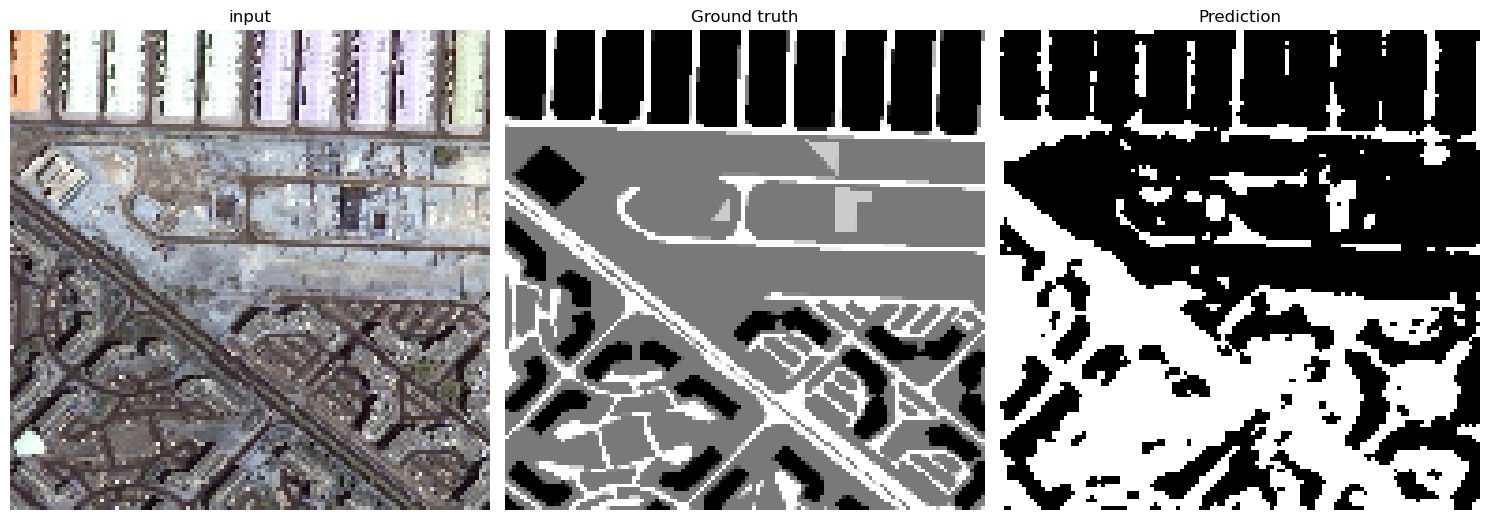

In [35]:
show_pred(11)